# Практическое задание №2: Работа с бинарными изображениями

## Задание 1

In [1]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
# from skimage import data, color, measure
# from scipy import ndimage

plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

Изображение загружено: размер (592, 740)


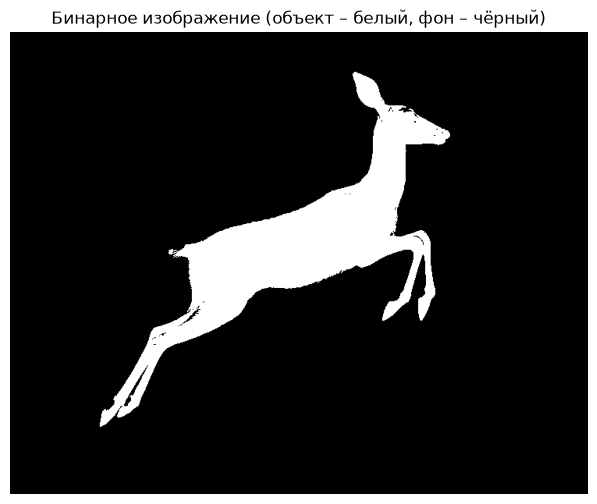

In [9]:
img_gray = np.array(Image.open('img2.jpg').convert('L'))

# Бинаризация методом Оцу (инвертируем, чтобы объект был белым, фон чёрным)
_, img_bin = cv2.threshold(img_gray, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f"Изображение загружено: размер {img_bin.shape}")
plt.imshow(img_bin, cmap='gray')
plt.title('Бинарное изображение (объект – белый, фон – чёрный)')
plt.axis('off')
plt.show()

Площадь объекта (нулевой момент): 42134 пикселей
Центроид: (374, 271)


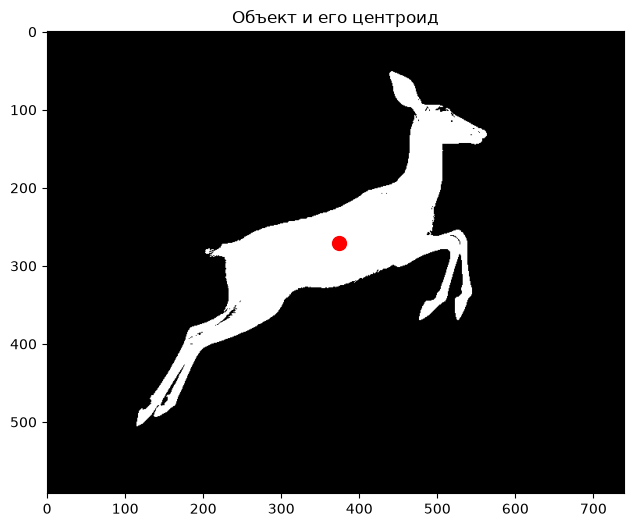

In [19]:
area1 = np.sum(img_bin)
print(f"Площадь объекта (нулевой момент): {area1} пикселей")
y1, x1 = np.where(img_bin == 1)   # координаты всех белых пикселей
M10 = np.sum(x1)
M01 = np.sum(y1)
centroid_x1 = M10 / area1
centroid_y1 = M01 / area1
print(f"Центроид: ({centroid_x1:.0f}, {centroid_y1:.0f})")

# Визуализация
plt.imshow(img_bin, cmap='gray')
plt.plot(centroid_x1, centroid_y1, 'ro', markersize=10)
plt.title('Объект и его центроид')
plt.show()

Угол ориентации в пространстве: -35.8°


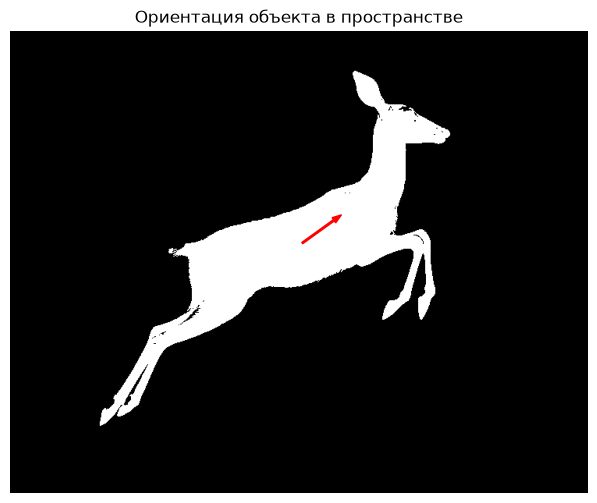

In [24]:
# Вычисление вторых центральных моментов
mu20 = np.sum((x1 - centroid_x1)**2)
mu02 = np.sum((y1 - centroid_y1)**2)
mu11 = np.sum((x1 - centroid_x1)*(y1 - centroid_y1))

angle = 0.5 * np.arctan2(2*mu11, mu20 - mu02)
angle_deg = np.degrees(angle)
print(f"Угол ориентации в пространстве: {angle_deg:.1f}°")

# Визуализируем направление
length = 50
dx = length * np.cos(angle)
dy = length * np.sin(angle)
plt.imshow(img_bin, cmap='gray')
plt.arrow(centroid_x1, centroid_y1, dx, dy, color='red', width=2, head_width=8)
plt.title('Ориентация объекта в пространстве')
plt.axis('off')
plt.show()

In [33]:
def erode(SE, name):
    kernel = cv2.getStructuringElement(SE, (7,7))
    eroded1 = cv2.erode(img_bin, kernel, iterations=1)

    plt.subplot(1,2,1); plt.imshow(img_bin, cmap='gray'); plt.title('Исходное изображение')
    plt.subplot(1,2,2); plt.imshow(eroded1, cmap='gray'); plt.title(f'Эрозия: SE - {name}')
    plt.show()

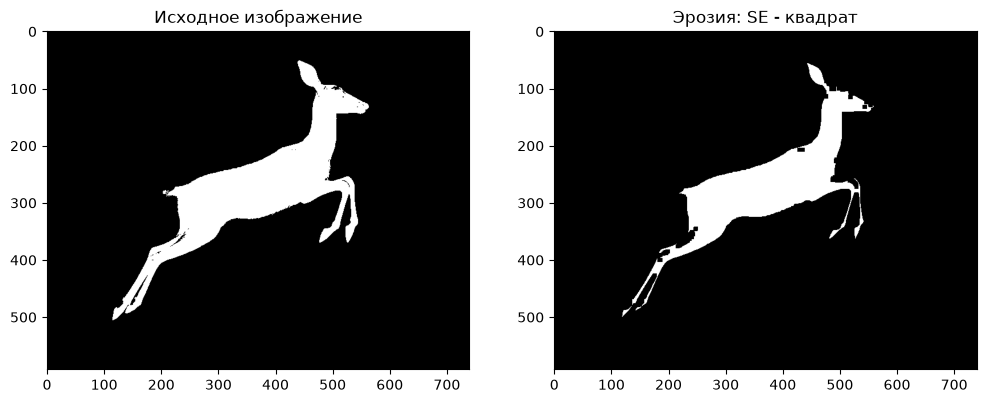

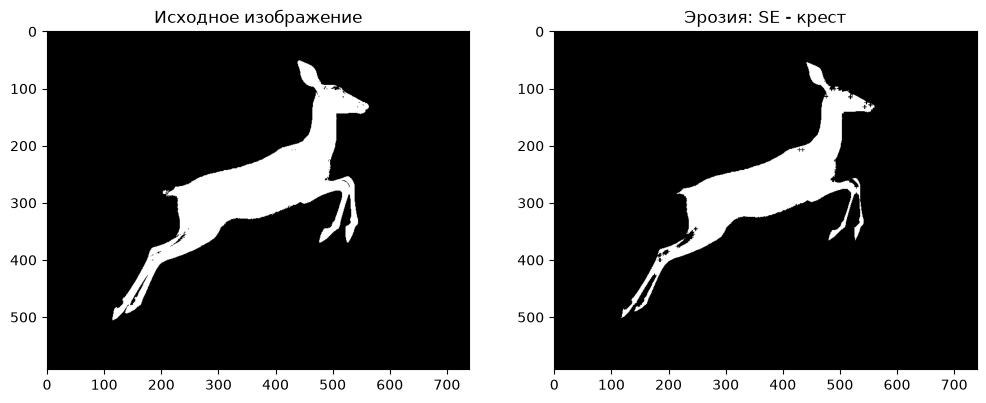

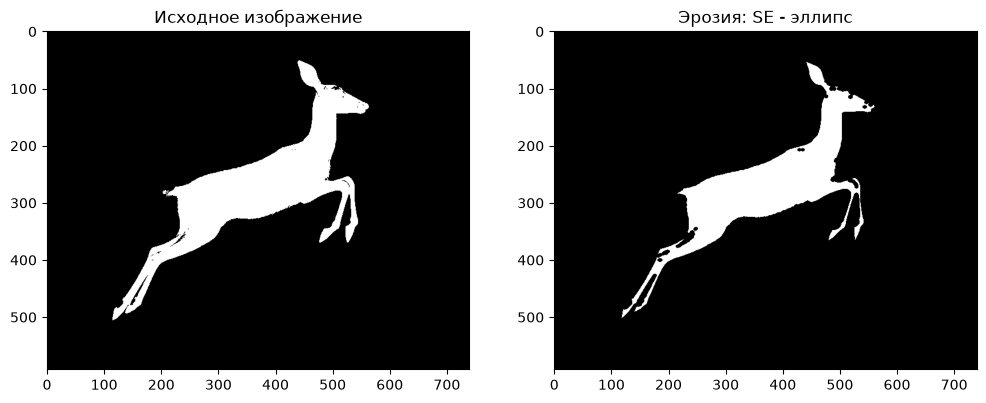

In [34]:
erode(cv2.MORPH_RECT, 'квадрат')
erode(cv2.MORPH_CROSS, 'крест')
erode(cv2.MORPH_ELLIPSE, 'эллипс')

- SE квадрат на угловых участках эрозирует изображение в форме квадрата.
- SE крест на угловых участках эрозирует изображение в форме креста.
- SE эллипс на угловых участках эрозирует изображение в форме эллипса.